In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [6]:
df['Age'].fillna(df['Age'].mean(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df.drop('Cabin', axis=1, inplace=True)

In [7]:
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [8]:
df['AgeGroup']=pd.cut(
df['Age'],
bins=[0,12,18,30,50,80],
labels=['Child','Teen','YoungAdult','Adult','Senior']
)

print(df[['Age','AgeGroup']].head())

    Age    AgeGroup
0  22.0  YoungAdult
1  38.0       Adult
2  26.0  YoungAdult
3  35.0       Adult
4  35.0       Adult


In [9]:
age_survival=df.groupby('AgeGroup')['Survived'].mean()
print(age_survival)

AgeGroup
Child         0.579710
Teen          0.428571
YoungAdult    0.331096
Adult         0.423237
Senior        0.343750
Name: Survived, dtype: float64


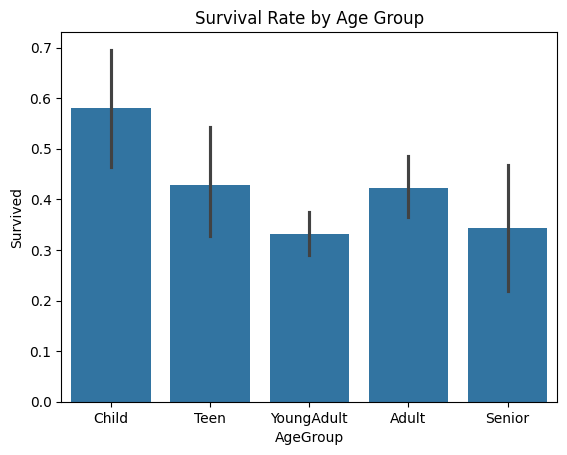

In [10]:
sns.barplot(x='AgeGroup',y='Survived',data=df)
plt.title('Survival Rate by Age Group')
plt.show()

In [11]:
embark_survival=df.groupby('Embarked')['Survived'].mean()
print(embark_survival)

Embarked
C    0.553571
Q    0.389610
S    0.339009
Name: Survived, dtype: float64


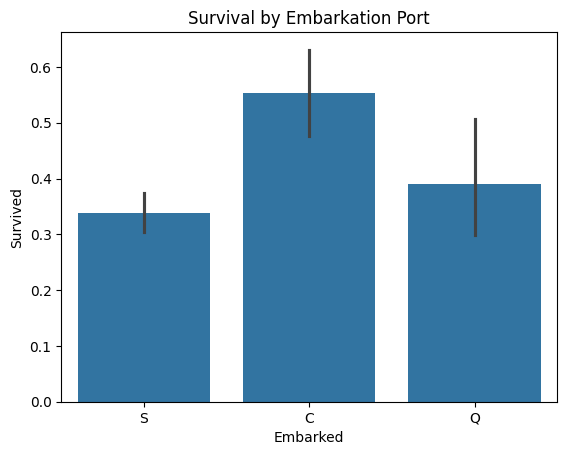

In [12]:
sns.barplot(x='Embarked',y='Survived',data=df)
plt.title("Survival by Embarkation Port")
plt.show()

In [15]:
df['FamilySize']=df['SibSp']+df['Parch']
print(df[['SibSp','Parch','FamilySize']].head())

   SibSp  Parch  FamilySize
0      1      0           1
1      1      0           1
2      0      0           0
3      1      0           1
4      0      0           0


In [16]:
family_survival=df.groupby('FamilySize')['Survived'].mean()
print(family_survival)

FamilySize
0     0.303538
1     0.552795
2     0.578431
3     0.724138
4     0.200000
5     0.136364
6     0.333333
7     0.000000
10    0.000000
Name: Survived, dtype: float64


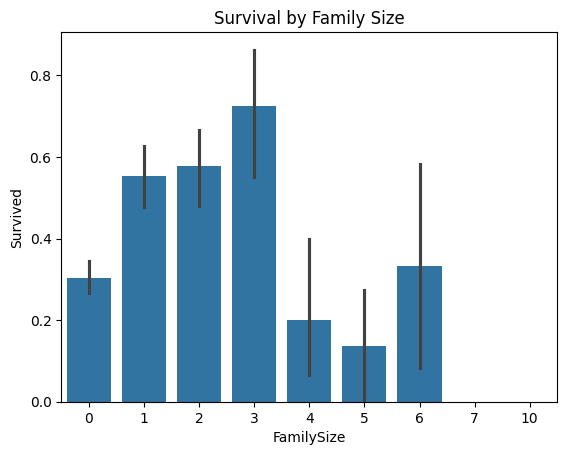

In [17]:
sns.barplot(x='FamilySize',y='Survived',data=df)
plt.title("Survival by Family Size")
plt.show()

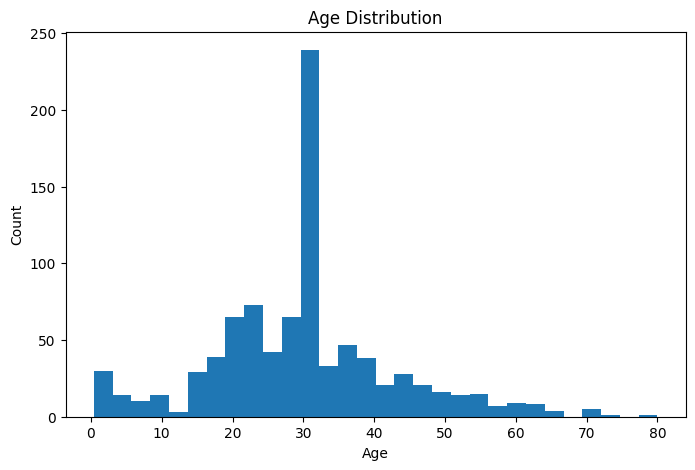

In [18]:
plt.figure(figsize=(8,5))

plt.hist(df['Age'],bins=30)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

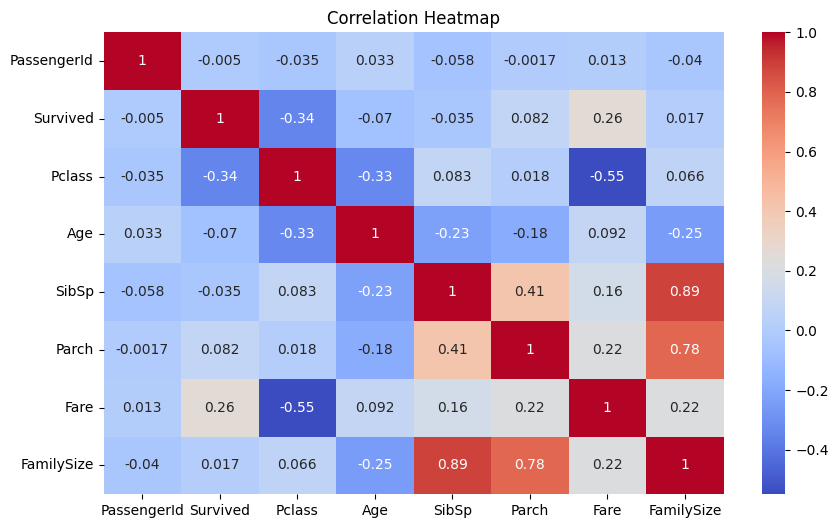

In [19]:
plt.figure(figsize=(10,6))

sns.heatmap(
df.corr(numeric_only=True),
annot=True,
cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()